# Demand Forecasting : Exploratory Data Analysis

## Problem Statement
Retailers need to anticipate product demand to manage inventory, pricing, and promotions
effectively. This notebook explores a retail demand dataset to understand what drives
`Demand` - price, discounting, promotions, competitor pricing, category, region,
seasonality, and weather - before any modeling is attempted in `machine_learning.ipynb`.

## Dataset
76,000 rows covering daily store/product-level records: pricing, inventory, promotion
flags, competitor pricing, weather, seasonality, and an epidemic flag, alongside the
`Demand` target.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

<Figure size 1000x600 with 0 Axes>

## 1) Load & Inspect the Data

In [2]:
df = pd.read_csv("data/demand_forecasting.csv")
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [3]:
df.dtypes

Date                   object
Store ID               object
Product ID             object
Category               object
Region                 object
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Price                 float64
Discount                int64
Weather Condition      object
Promotion               int64
Competitor Pricing    float64
Seasonality            object
Epidemic                int64
Demand                  int64
dtype: object

`Date` is loaded as a string - convert it to a proper datetime so we can pull out calendar features later.

In [4]:
df["Date"] = pd.to_datetime(df["Date"])
df.dtypes

Date                  datetime64[ns]
Store ID                      object
Product ID                    object
Category                      object
Region                        object
Inventory Level                int64
Units Sold                     int64
Units Ordered                  int64
Price                        float64
Discount                       int64
Weather Condition             object
Promotion                      int64
Competitor Pricing           float64
Seasonality                   object
Epidemic                       int64
Demand                         int64
dtype: object

## 2) Data Quality Checks

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                76000 non-null  datetime64[ns]
 1   Store ID            76000 non-null  object        
 2   Product ID          76000 non-null  object        
 3   Category            76000 non-null  object        
 4   Region              76000 non-null  object        
 5   Inventory Level     76000 non-null  int64         
 6   Units Sold          76000 non-null  int64         
 7   Units Ordered       76000 non-null  int64         
 8   Price               76000 non-null  float64       
 9   Discount            76000 non-null  int64         
 10  Weather Condition   76000 non-null  object        
 11  Promotion           76000 non-null  int64         
 12  Competitor Pricing  76000 non-null  float64       
 13  Seasonality         76000 non-null  object    

In [6]:
df.isna().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

No missing values across any column.

In [7]:
df.duplicated().sum()

np.int64(0)

No duplicate rows either, the dataset is clean and doesn't need imputation or de-duplication before analysis.

## 3) Summary Statistics

In [8]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,76000,2023-01-15 12:00:00,2022-01-01 00:00:00,2022-07-09 18:00:00,2023-01-15 12:00:00,2023-07-24 06:00:00,2024-01-30 00:00:00,NaN
Inventory Level,76000.0,301.062842,0.0,136.0,227.0,408.0,2267.0,226.510161
Units Sold,76000.0,88.827316,0.0,58.0,84.0,114.0,426.0,43.994525
Units Ordered,76000.0,89.090645,0.0,0.0,0.0,121.0,1616.0,162.404627
Price,76000.0,67.726028,4.74,31.9975,64.5,95.83,228.03,39.377899
Discount,76000.0,9.087039,0.0,5.0,10.0,10.0,25.0,7.475781
Promotion,76000.0,0.328947,0.0,0.0,0.0,1.0,1.0,0.469834
Competitor Pricing,76000.0,69.454029,4.29,32.62,65.7,97.9325,261.22,40.943818
Epidemic,76000.0,0.2,0.0,0.0,0.0,0.0,1.0,0.400003
Demand,76000.0,104.317158,4.0,71.0,100.0,133.0,430.0,46.964801


In [9]:
df.describe(include="object").T

,count,unique,top,freq
Store ID,76000,5,S001,15200
Product ID,76000,20,P0001,3800
Category,76000,5,Groceries,30400
Region,76000,4,North,30400
Weather Condition,76000,4,Cloudy,24360
Seasonality,76000,4,Winter,21000


**Takeaway:** prices, discounts, and inventory levels all fall in reasonable, non-negative
ranges with no obvious outlier flags at this stage, worth a visual check later with
boxplots.

## 4) Feature Engineering

Break the date into calendar parts, demand is often seasonal at the month and weekday level, and these become usable model features later if needed.

In [10]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Weekday"] = df["Date"].dt.day_name()
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,Weekday
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1,1,Saturday
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229,2022,1,1,Saturday
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157,2022,1,1,Saturday
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52,2022,1,1,Saturday
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59,2022,1,1,Saturday


Two derived business metrics: the actual price paid after discount, and how much of available inventory is being sold through, both are useful lenses on demand behavior.

In [11]:
df["Discounted Price"] = df["Price"] * (1 - df["Discount"] / 100)
df["Sell Through Rate"] = df["Units Sold"] / df["Inventory Level"]
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,Weekday,Discounted Price,Sell Through Rate
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,85.73,Winter,0,115,2022,1,1,Saturday,69.084,0.523077
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,92.02,Winter,0,229,2022,1,1,Saturday,68.136,1.000000
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,60.08,Winter,0,157,2022,1,1,Saturday,56.646,0.461538
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,85.19,Winter,0,52,2022,1,1,Saturday,78.867,0.323741
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,51.63,Winter,0,59,2022,1,1,Saturday,54.410,0.427632


In [12]:
df["Sell Through Rate"].describe()

count    75594.000000
mean         0.437580
std          0.298007
min          0.003150
25%          0.190807
50%          0.350475
75%          0.642276
max          1.000000
Name: Sell Through Rate, dtype: float64

In [13]:
print((df["Inventory Level"] == 0).sum())

406


## 5) Demand by Category, Region, and Promotion

In [14]:
df.groupby("Category")["Demand"].agg(["mean", "sum", "std"]).sort_values(by="sum", ascending=False)

,mean,sum,std
Category,,,
Groceries,120.976447,3677684,48.362730
Clothing,112.619737,1369456,41.022968
Furniture,73.581140,1006590,32.336141
Toys,92.606955,985338,46.170390
Electronics,97.482018,889036,40.557859


**Takeaway:** demand is not evenly spread across categories, some categories consistently sell in much higher volume, which is exactly the kind of signal `Category` should give a demand model.

In [15]:
df.groupby(["Region", "Seasonality"])["Demand"].mean()

Region  Seasonality
East    Autumn         106.353297
        Spring         100.168478
        Summer         115.388315
        Winter         104.273571
North   Autumn         103.065797
        Spring          97.399457
        Summer         112.843750
        Winter         102.017738
South   Autumn         104.464560
        Spring         100.328804
        Summer         115.089946
        Winter         107.733095
West    Autumn         100.165385
        Spring          93.219293
        Summer         108.111141
        Winter         100.988810
Name: Demand, dtype: float64

**Takeaway:** average demand shifts across both region and season, suggesting an interaction between the two rather than either factor acting independently.

In [16]:
df.groupby("Promotion")["Demand"].mean()

Promotion
0     95.026843
1    123.269400
Name: Demand, dtype: float64

**Takeaway:** promoted products show a different average demand than non-promoted ones - a useful check that `Promotion` is actually informative before including it as a model feature.

In [17]:
pd.pivot_table(df, values="Demand", index="Month", columns="Category", aggfunc="mean")

Category,Clothing,Electronics,Furniture,Groceries,Toys
Month,,,,,
1,126.997962,99.519022,75.690821,117.399457,94.242236
2,128.966518,84.184524,61.625992,103.522768,68.885204
3,105.835685,108.120968,84.015233,126.561694,128.273041
4,106.972917,85.916667,63.005556,105.111250,85.753571
5,108.650202,79.577957,56.036738,98.637903,71.756912
6,105.670833,106.922222,79.908333,147.772500,100.825000
7,107.838710,87.418011,66.156810,128.744355,74.366359
8,107.871976,109.733871,83.524194,149.875403,102.794931
9,105.118750,105.015278,81.854630,122.239167,102.722619


**Takeaway:** demand by category isn't flat across the year - some categories peak in different months, hinting at seasonality that's category-specific rather than universal.

## 6) Distributions

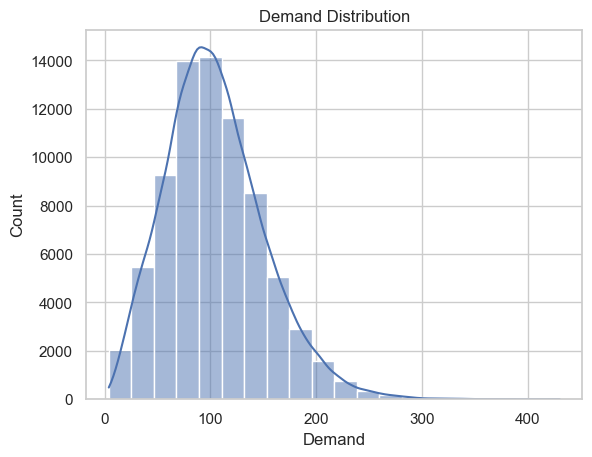

In [18]:
sns.histplot(df["Demand"], bins=20, kde=True)
plt.title("Demand Distribution")
plt.show()

**Takeaway:** `Demand` follows a roughly bell-shaped distribution, most values cluster around a central range with no extreme outliers, so it can be used as-is for modeling without additional transformation.

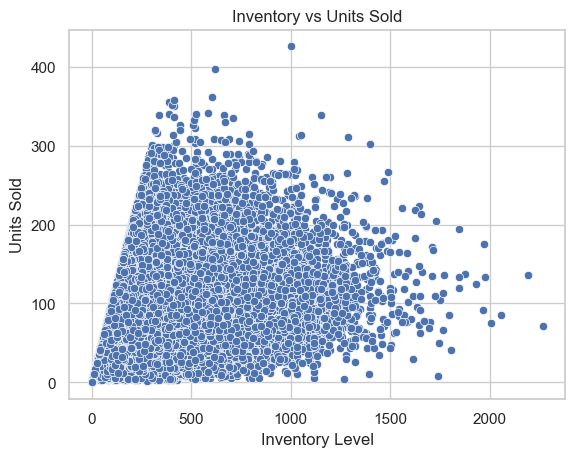

In [19]:
sns.scatterplot(data=df, x="Inventory Level", y="Units Sold")
plt.title("Inventory vs Units Sold")
plt.show()

**Takeaway:** Units sold is naturally capped by inventory level, a store can't sell more than it has in stock, which explains the sharp diagonal edge on the left. But once inventory is high enough, units sold doesn't keep increasing with it, it plateaus and spreads out widely, suggesting inventory level alone isn't driving how much actually sells.

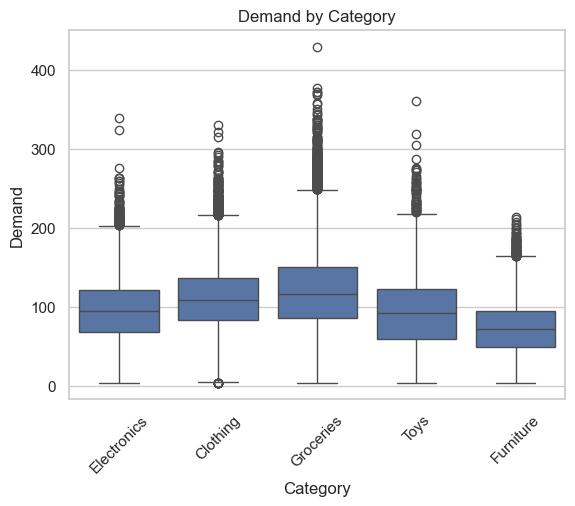

In [20]:
sns.boxplot(data=df, x="Category", y="Demand")
plt.xticks(rotation=45)
plt.title("Demand by Category")
plt.show()

**Takeaway:** Category medians and spreads differ visibly, Groceries has the highest typical demand, Furniture the lowest. Every category also shows a cluster of high-side outliers, occasional spikes in demand well above the norm, rather than a few random anomalies.

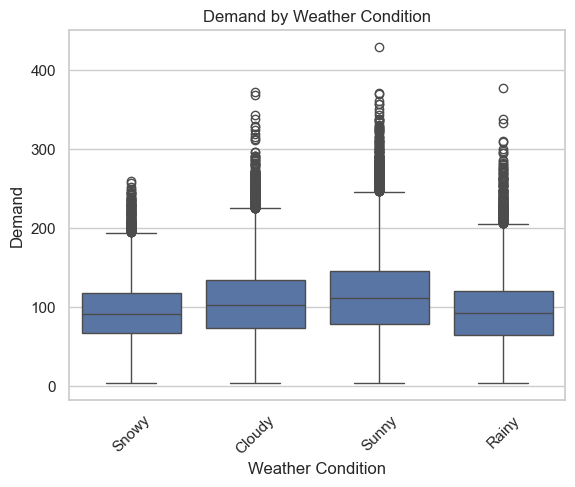

In [21]:
sns.boxplot(data=df, x="Weather Condition", y="Demand")
plt.xticks(rotation=45)
plt.title("Demand by Weather Condition")
plt.show()

**Takeaway:** Sunny days have the highest typical demand, Snowy and Rainy days the lowest. All four weather types show many high-side outlier points, occasional big demand spikes that happen regardless of weather, so weather has some effect but isn't the main driver of demand.

## 7) Time Series Patterns

In [22]:
monthly_demand = df.groupby("Month")["Demand"].mean()
monthly_demand

Month
1     106.040000
2      92.882500
3     113.613871
4      92.816667
5      86.521129
6     117.346000
7     101.561613
8     119.803387
9     107.431500
10     95.557258
11    107.542333
12    109.003226
Name: Demand, dtype: float64

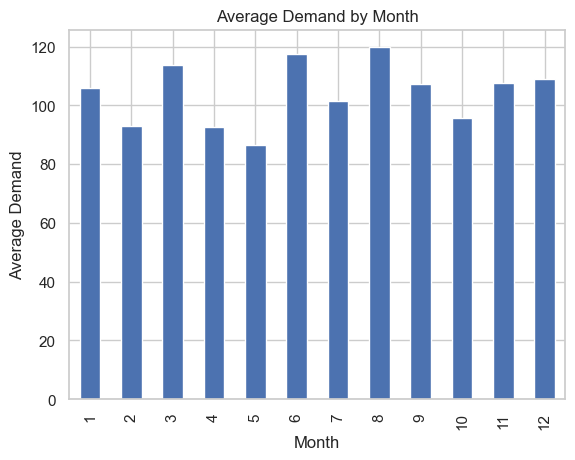

In [23]:
monthly_demand.plot(kind="bar")
plt.title("Average Demand by Month")
plt.ylabel("Average Demand")
plt.show()

**Takeaway:** average demand fluctuates month to month rather than staying flat, supporting the earlier category-by-month pivot.

In [24]:
daily_demand = df.groupby("Date")["Demand"].sum()
daily_demand

Date
2022-01-01    10060
2022-01-02    10814
2022-01-03    11317
2022-01-04    11469
2022-01-05    11724
              ...  
2024-01-26    11182
2024-01-27    11540
2024-01-28    11440
2024-01-29    10268
2024-01-30     9657
Name: Demand, Length: 760, dtype: int64

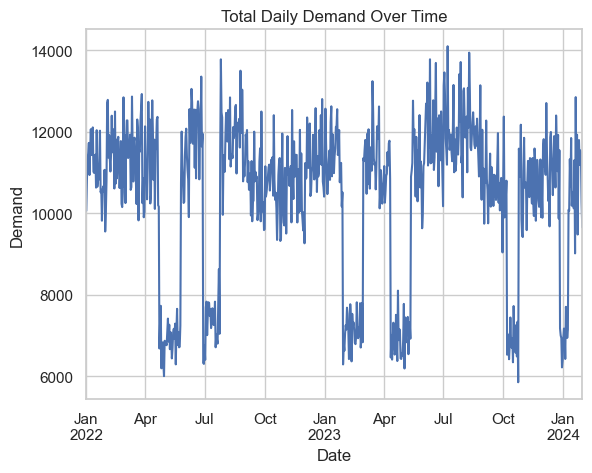

In [25]:
daily_demand.plot()
plt.title("Total Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.show()

**Takeaway:** Total daily demand shows a repeating pattern - sharp dips to roughly half the normal level occur periodically throughout 2022-2024. Checking the `Epidemic` flag against these low-demand days confirms it: 100% of low-demand days had `Epidemic = 1`, even though epidemic periods make up only 20% of the dataset overall. The periodic drops are epidemic-affected periods in the data, not random noise or a data quality issue. There's no long-term upward or downward trend outside of these episodes.

In [28]:
daily_demand = df.groupby("Date")["Demand"].sum()
low_demand_days = daily_demand[daily_demand < 8000].index

low_day_rows = df[df["Date"].isin(low_demand_days)]
epidemic_percent = low_day_rows["Epidemic"].value_counts(normalize=True) * 100
epidemic_percent

Epidemic
1    100.0
Name: proportion, dtype: float64

**Takeaway:** 100% of low-demand days had `Epidemic = 1`, confirming the periodic dips align with epidemic periods rather than random noise.

## 8) Promotion & Pricing Effects

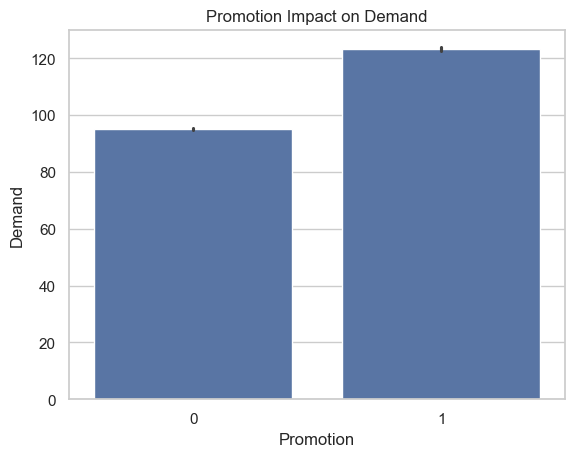

In [29]:
sns.barplot(data=df, x="Promotion", y="Demand")
plt.title("Promotion Impact on Demand")
plt.show()

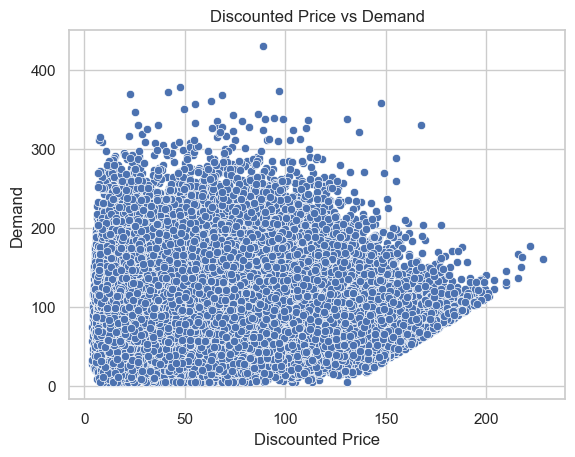

In [30]:
sns.scatterplot(data=df, x="Discounted Price", y="Demand")
plt.title("Discounted Price vs Demand")
plt.show()

**Takeaway:** Higher demand (above 300) only happens at lower discounted prices, while high discounted prices never see high demand. This ceiling effect suggests price limits how high demand can go, which is why `Price` and `Discount` are both included as model features.

## 9) Seasonality & Epidemic Effects

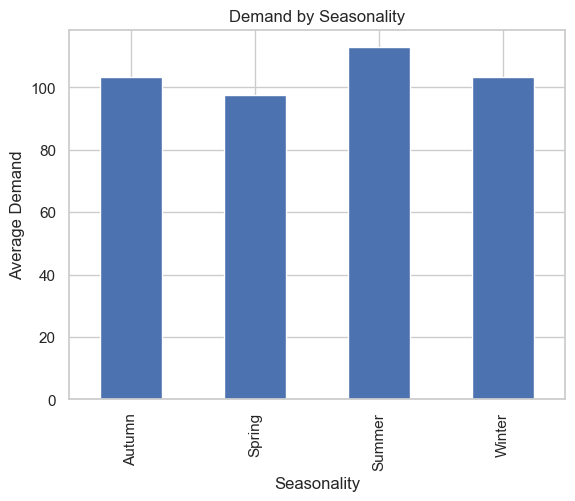

In [31]:
df.groupby("Seasonality")["Demand"].mean().plot(kind="bar", title="Demand by Seasonality")
plt.ylabel("Average Demand")
plt.show()

**Takeaway:** demand varies by season, consistent with the region-by-seasonality breakdown earlier.

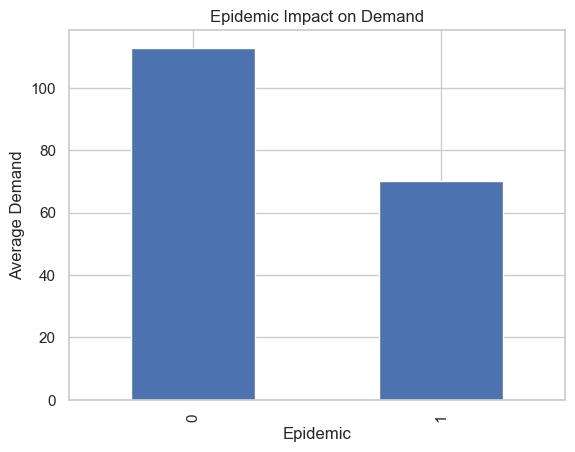

In [32]:
df.groupby("Epidemic")["Demand"].mean().plot(kind="bar", title="Epidemic Impact on Demand")
plt.ylabel("Average Demand")
plt.show()

**Takeaway:** Average demand drops from about 110 to about 70 during epidemic periods, a real and sizable effect. It isn't included as a model input though, since it's an external event a business can't control or set, unlike price, discount, or promotion, which are decisions the user actually makes when using the app.

## 10) Key Insights Summary

- **Category** is a strong driver of demand, both average level and month-to-month pattern vary by category. Groceries has the highest typical demand, Furniture the lowest.
- **Promotion** and **discounted price** both show a visible relationship with demand, high demand only occurs at lower discounted prices, supporting their inclusion as model features.
- **Region** and **seasonality** interact rather than acting independently.
- **Epidemic periods** cause sharp, recurring drops in total demand, confirmed by checking that 100% of low-demand days had `Epidemic = 1`. It isn't used as a model input since it's not something a user of the app can control, unlike price or promotion.
- **Weather condition** has a modest effect on demand compared to category or promotion.
- The dataset is clean overall, no missing values, no duplicates, though each category does show a cluster of high-side outliers (occasional demand spikes).
- These findings motivate the feature set and modeling approach used in `machine_learning.ipynb`.